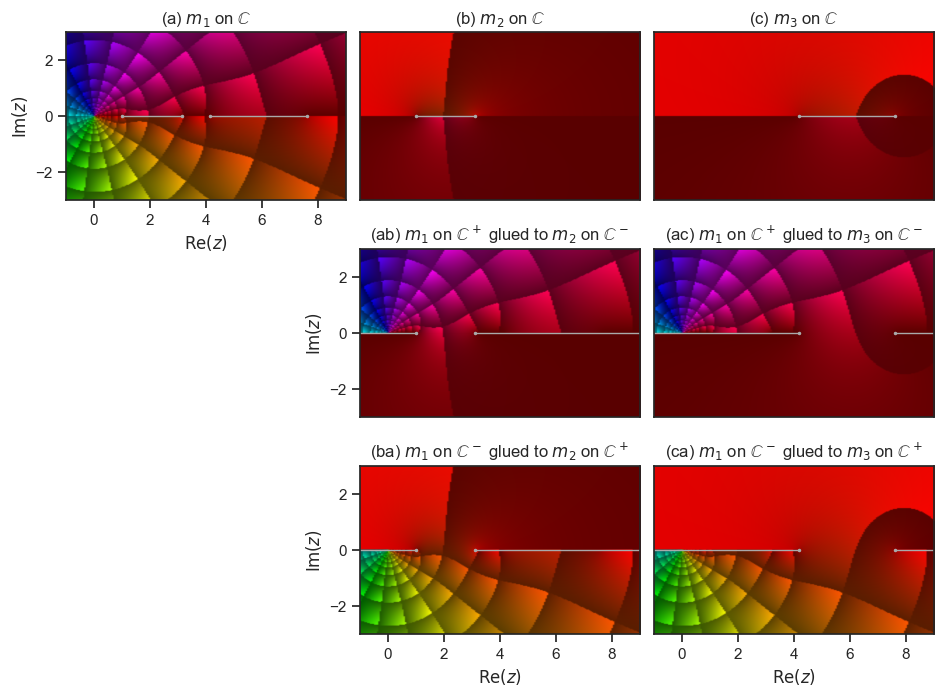

In [1]:
# Install ;#\freealg#; with ;#"\texttt{pip install \freealg}"#;
import freealg as fa
import numpy as np

# Create an object for the Compound Free Poisson distribution (see ;# \Cref{sec:compound-poisson}#;)
dist = fa.distributions.CompoundFreePoisson(t=[2, 5.5], w=[0.75, 0.25], lam=0.1)

# Visualize all branches and their gluing as in ;# \Cref{fig:cfp-branches} #;
x = np.linspace(-1, 9, 200)
y = np.linspace(-3, 3, 200)
dist.plot_branches(x, y)

# Generate a matrix realization of size ;#$ n=\num{8000} $#; for this distribution
A_large = dist.matrix(size=8000, seed=0)

# Sample the above matrix to a smaller submatrix of size ;#$ n_0 = \num{1000} $#;
A_small = fa.submatrix(A_large, 1000, seed=0)

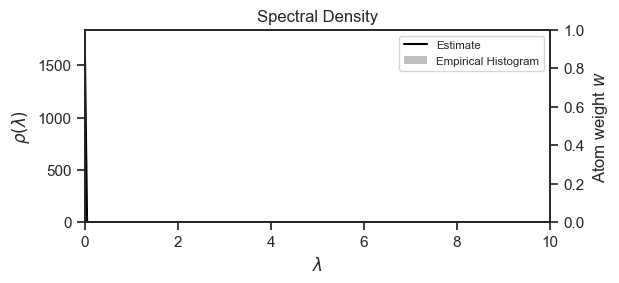

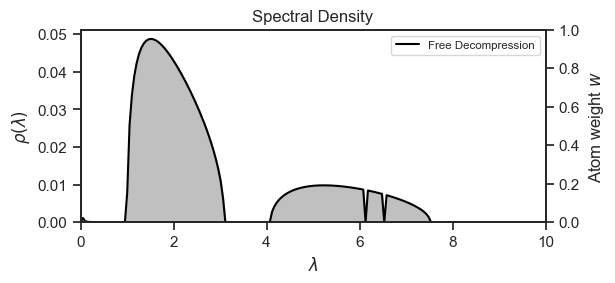

In [2]:
# Create an algebraic-form object for the small matrix
af = fa.AlgebraicForm(A_small)

# Fit the polynomial ;#$ P $#; with ;#$ \deg_m(P) = 3 $#; and ;#$ \deg_z(P) = 1 $#; (see ;# \Cref{alg:poly}#;)
af.fit(deg_m=3, deg_z=1)

# Estimate the density of the small matrix from ;#$ P $#; using ;# \Cref{alg:stieltjes} #;
x = np.linspace(0, 10, 200)
rho_small = af.density(x, plot=True)

# Free decompression of density and atoms corresponding to a larger matrix of
# size ;#$ n = \num{8000} $#; using ;# \Cref{alg:decompress} #; (see ;# \Cref{fig:cfp-flow} #;). 
rho_large, atoms_large = af.decompress(
    size=8000, x=x, kind='free', return_atoms=True, plot=True)

# Evolve spectral edges from the small to the large matrix size using ;# \Cref{alg:edge} #;
# Also this find cusp points where the bulks split (see ;# \Cref{fig:cfp-atom}#;)
sizes = np.linspace(1000, 8000, 100)
t = np.log(sizes / 1000)
edges, cusps = af.edge(t, kind='free')